<font size = "5"> **EDS_Tools:  [Spectroscopy](../4_EELS_Tools.ipynb)** </font>

<hr style="height:1px;border-top:4px solid #FF8200" />

# Analysis of EDS Spectra
<br>

[<img src=https://www.coeuscreativegroup.com/wp-content/uploads/2020/04/download-button.png, width=125>](https://raw.githubusercontent.com/pycroscopy/pyTEMlib/main/notebooks/Spectroscopy/EDS.ipynb) 

[![OpenInColab](https://colab.research.google.com/assets/colab-badge.svg)](
    https://colab.research.google.com/github/pycroscopy/pyTEMlib/blob/main/notebooks/Spectroscopy/EDS.ipynb)
    
part of 

<font size = "5"> **[pyTEMlib](https://pycroscopy.github.io/pyTEMlib/about.html)**</font>

a [pycroscopy](https://pycroscopy.github.io/pycroscopy/about.html) ecosystem package



Notebook by Gerd Duscher, 2025

Microscopy Facilities<br>
Institute of Advanced Materials & Manufacturing<br>
The University of Tennessee, Knoxville

Model based analysis and quantification of data acquired with transmission electron microscopes

## Content
An Introduction into displaying and analyzing EDS spectrum images and spectra
This works also on Google Colab.


## Prerequesites

### Install pyTEMlib

If you have not done so in the [Introduction Notebook](_.ipynb), please test and install [pyTEMlib](https://github.com/gduscher/pyTEMlib) and other important packages with the code cell below.


In [ ]:
import sys
import importlib.metadata

def test_package(package_name):
    """Test if package exists and returns version or -1"""
    try:
        version = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        version = '-1'
    return version


# pyTEMlib setup ------------------
if test_package('pyTEMlib') < '0.2026.1.1':
    print('installing pyTEMlib')
   
    !{sys.executable} -m pip install pyTEMlib --upgrade
# ------------------------------
print('done')

### Loading of necessary libraries

Please note, that we only need to load the pyTEMlib library, which is based on sidpy Datsets.



In [54]:
%matplotlib inline
import sys
import numpy as np
import matplotlib.pylab as plt

import pyTEMlib

if 'google.colab' in sys.modules:
    from google.colab import output
    output.enable_custom_widget_manager()
    from google.colab import drive

if 'google.colab' in sys.modules:
    drive.mount("/content/drive")

# For archiving reasons it is a good idea to print the version numbers out at this point
print('pyTEM version: ',pyTEMlib.__version__)
__notebook__ = 'EDS_Spectrum_Analysis'
__notebook_version__ = '2026_1_19'

pyTEM version:  0.2026.1.3


## Open File

### Load File

Select a main dataset and any additional data like reference data and such.

In [ ]:
# C:\Users\gduscher\OneDrive - University of Tennessee\google_drive\2022 Experiments\Spectra\20221214\AlCe-200kV
file_name = "data-old-eds/EDS-STO.emd"
data = pyTEMlib.file_tools.open_file(file_name)
data['SuperX'].metadata['EDS']['detector']

{'Detector-0': {'DetectorName': 'BF-S', 'DetectorType': 'ScanningDetector', 'Inserted': 'false', 'Enabled': 'true', 'Gain': '39', 'Offset': '0', 'CollectionAngleRange': {'begin': '0', 'end': '0'}}, 'Detector-1': {'DetectorName': 'BM-Ceta', 'DetectorType': 'ImagingDetector', 'ExposureMode': '', 'Binning': {'width': '4', 'height': '4'}, 'ReadOutArea': {'left': '0', 'top': '0', 'right': '1024', 'bottom': '1024'}, 'ExposureTime': '0.10000000000000001', 'Shutters': {'Shutter-0': {'Position': 'PostSpecimen', 'Type': 'Electrostatic'}}, 'DarkGainCorrectionType': '3'}, 'Detector-2': {'DetectorName': 'DF-S', 'DetectorType': 'ScanningDetector', 'Inserted': 'false', 'Enabled': 'true', 'Gain': '45.659520000000015', 'Offset': '-4.0012542384708496e-08', 'CollectionAngleRange': {'begin': '0', 'end': '0'}}, 'Detector-3': {'DetectorName': 'EF-CCD', 'DetectorType': 'ImagingDetector', 'ExposureMode': '', 'Binning': {'width': '4', 'height': '4'}, 'ReadOutArea': {'left': '0', 'top': '0', 'right': '1024', 'b

{'detector': {'layers': {13: {'thickness': 5e-08, 'Z': 13, 'element': 'Al'}},
  'SiDeadThickness': 1.3e-07,
  'SiLiveThickness': 0.05,
  'detector_area': 2.9999999999999997e-05,
  'energy_resolution': 125,
  'start_energy': 120,
  'start_channel': 100,
  'ElevationAngle': 0.31415927,
  'AzimuthAngle': 3.9269908169872414,
  'RealTime': 26.2338126,
  'LiveTime': 25.20496870466589}}

In [86]:
## autpscript
from autoscript_tem_microscope_client import TemMicroscopeClient
from autoscript_tem_microscope_client.enumerations import EdsDetectorType, ExposureTimeType
from autoscript_tem_microscope_client.structures import EdsAcquisitionSettings
import numpy as np
import os
from pathlib import Path
import json
ip = os.getenv("MICROSCOPE_IP")
port = os.getenv("MICROSCOPE_PORT")

if not ip or not port:
    secret_path = Path("../../config_secret.json")
    if secret_path.exists():
        with open(secret_path, "r") as f:
            secret = json.load(f)
            ip = ip or secret.get("ip_TF")
            port = port or secret.get("port_TF")

if not ip:
    ip = input("Enter microscope IP: ")
if not port:
    port = input("Enter microscope Port: ")
port = int(port)


# # Connect to the microscope
microscope = TemMicroscopeClient()
microscope.connect(ip, port=port)

# Get the first EDS detector
eds_detector_name = microscope.detectors.eds_detectors[0]
eds_detector = microscope.detectors.get_eds_detector(eds_detector_name)

# Configure the acquisition
settings = EdsAcquisitionSettings()
settings.eds_detector = eds_detector_name
settings.dispersion = eds_detector.dispersions[-2]# 10 ev per channel
settings.shaping_time = eds_detector.shaping_times[-1]
settings.exposure_time = 2
settings.exposure_time_type = ExposureTimeType.LIVE_TIME

# Run the spectrum acquisition
spectrum = microscope.analysis.eds.acquire_spectrum(settings)


Client connecting to [10.46.217.241:9095]...
Client connected to [10.46.217.241:9095]


In [ ]:
# eds_detector.dispersions

[1.0, 2.0, 5.0, 10.0, 20.0]

In [10]:
spectrum.data

array([0, 0, 0, ..., 0, 0, 0], shape=(4096,), dtype=uint32)

In [92]:
import copy

In [94]:
spectrum_saved2 = copy.copy(spectrum)

In [110]:
import xmltodict
xml_string = spectrum_saved.metadata.metadata_as_xml
metadata = xmltodict.parse(xml_string)
metadata = json.loads(json.dumps(metadata))
detectors = metadata["Metadata"]["Detectors"]["AnalyticalDetector"]
# If only one detector, wrap it into a list
if isinstance(detectors, dict):
    detectors = [detectors]

# Take the first detector (or filter by name if needed)
det = detectors[0]
dispersion = float(det.get("Dispersion", 0))
offset = float(det.get("OffsetEnergy", 0))


In [141]:
from __future__ import annotations

from pathlib import Path
from typing import Any, Optional
import numpy as np


def save_autoscript_spectrum(
    spectrum: Any,
    out_dir: str | Path,
    stem: str = "spectrum",
) -> tuple[Path, Path]:
    """
    Save AutoScript AdornedSpectrum data + XML metadata to disk.

    Writes:
      - <stem>.npz  (data array)
      - <stem>.xml  (metadata as XML)
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    npz_path = out_dir / f"{stem}.npz"
    xml_path = out_dir / f"{stem}.xml"

    # --- save raw spectrum data ---
    np.savez_compressed(npz_path, data=np.asarray(spectrum.data))

    # --- save XML metadata string ---
    xml_string = spectrum.metadata.metadata_as_xml
    xml_path.write_text(xml_string, encoding="utf-8")

    return npz_path, xml_path

In [142]:
npz_path, xml_path = save_autoscript_spectrum(spectrum_saved, "my_run", stem="eds_0001")
print(npz_path, xml_path)

my_run/eds_0001.npz my_run/eds_0001.xml


In [96]:
dispersion

10.0

In [20]:
offset

-250.0

In [27]:
import sidpy
dataset = sidpy.Dataset.from_array(spectrum.data)
#dataset.set_dimension(0, sidpy.Dimension('energy', np.arange(dataset.shape[0])*dispersion+offset, unit='eV'))

print(dataset)
np.arange(dataset.shape[0])*dispersion+offset,

sidpy.Dataset of type UNKNOWN with:
 dask.array<array, shape=(4096,), dtype=uint32, chunksize=(4096,), chunktype=numpy.ndarray>
 data contains: generic (generic)
 and Dimensions: 
a:  generic (generic) of size (4096,)


(array([ -250.,  -230.,  -210., ..., 81610., 81630., 81650.], shape=(4096,)),)

To properly construct a sidpy.Dataset for a spectrum, you need to:
- Create the dataset from the intensity array
- Define the spectral dimension (energy axis)
- Assign metadata like quantity, units, data_type

Right now you’re creating the dataset correctly from the array, but you haven’t attached the energy axis as a Dimension.

In [111]:
# intensity values
intensity = np.array(spectrum_saved.data)  

# create energy axis
energy = np.arange(intensity.shape[0]) * dispersion*1.006 + offset

# create dataset
dataset = sidpy.Dataset.from_array(intensity)

# set dimension (axis 0 = spectral axis)
dataset.set_dimension(
    0,
    sidpy.Dimension(
        values=energy,
        name='Energy',
        units='eV',
        quantity='Energy',
        dimension_type='spectral'
    )
)

# optional but recommended metadata
dataset.quantity = 'Intensity'
dataset.units = 'a.u.'  # or 'counts'
dataset.data_type = 'spectrum'

print(dataset)

sidpy.Dataset of type SPECTRUM with:
 dask.array<array, shape=(4096,), dtype=uint32, chunksize=(4096,), chunktype=numpy.ndarray>
 data contains: Intensity (a.u.)
 and Dimensions: 
Energy:  Energy (eV) of size (4096,)


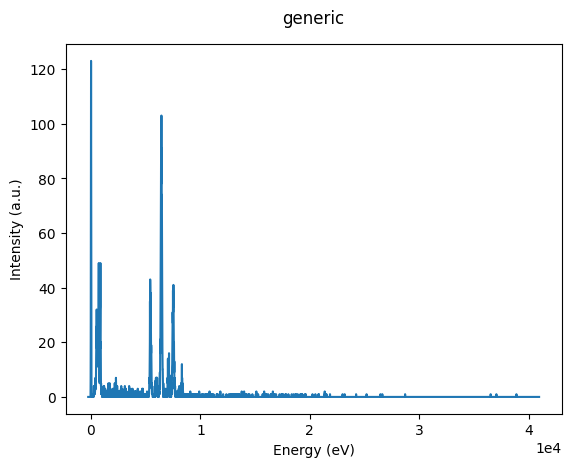

In [112]:
view = dataset.plot()

### Select and Plot Dataset

Select a dataset from the drop down value and display it with the code cell below.

Here we sum the spectra of the 4 quadrants and define the detector parameter.

In [113]:
# import SciFiReaders as sr
# reader = sr.EMDReader(file_path=file_name)
# spectrum = reader.read()

In [114]:
# # spectrum = fileWidget.selected_dataset#---> sidpy dataset
# datasets = pyTEMlib.file_tools.open_file(filename=file_name, sum_frames = False)
# dataset_list = []
# for key in datasets.keys():
#     dataset_list.append(f'{key}: {datasets[key].title}')
# # loaded_datasets.options = dataset_list
# # loaded_datasets.value = dataset_list[0]
# dataset = datasets[list(datasets.keys())[0]]
# selected_dataset = dataset


In [115]:
# spectrum = selected_dataset
# view = spectrum.plot()

In [116]:
### Does not work for spectrum images
# 
spectrum = dataset
import pyTEMlib
start = np.searchsorted(spectrum.Energy.values, 100)
energy_scale = spectrum.Energy.values[start:]
spectrum.metadata.setdefault('EDS', {})
spectrum.metadata['EDS'].setdefault('detector', {})
spectrum.metadata['EDS']['detector'] = data['SuperX'].metadata['EDS']['detector']
#detector_Efficiency= pyTEMlib.eds_tools.detector_response(spectrum)  # tags, spectrum.energy_scale.values[start:])


spectrum.metadata['EDS']['detector'].setdefault('start_energy',  120)
spectrum.metadata['EDS']['detector']['start_channel'] = np.searchsorted(spectrum.Energy.values, spectrum.metadata['EDS']['detector']['start_energy'])
start = spectrum.metadata['EDS']['detector']['start_channel']
# spectrum[:spectrum.metadata['EDS']['detector']['start_channel']] = 100.

spectrum.metadata['EDS']['detector']['detector_efficiency']  = detector_Efficiency

In [144]:
pyTEMlib.eds_tools.detector_response(spectrum)

array([0.        , 0.        , 0.        , ..., 0.99341267, 0.99338575,
       0.99335873], shape=(4096,))

In [143]:
detector_Efficiency

array([0.        , 0.        , 0.        , ..., 0.42361276, 0.42332734,
       0.42304178], shape=(4096,))

## Find Elements 
The minimum_number_of_peaks determines how many elements will be found. 

Increase from 10 to 11 of that parameter will reveal Nb a common dopant of SrTiO$_3$

/nfs/home/upratius/scratch_i24/projects/pyAutoMic/TEM/stemOrchestrator/.venv/lib/python3.11/site-packages/dask/array/core.py:1738: FutureWarning: The `numpy.argsort` function is not implemented by Dask array. You may want to use the da.map_blocks function or something similar to silence this warning. Your code may stop working in a future release.
  warnings.warn(


['O', 'Fe', 'Ne', 'F', 'Ni', 'Cr']

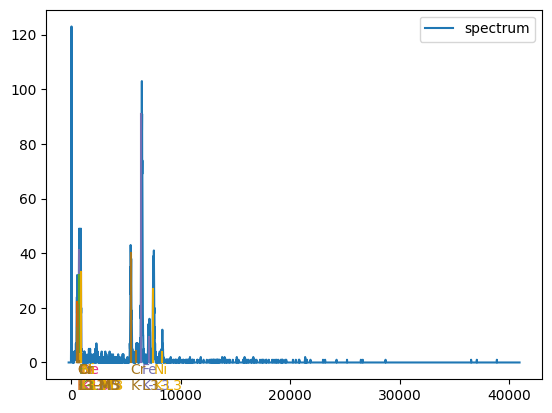

In [117]:
# --------Input -----------
minimum_number_of_peaks = 10
# --------------------------

elements = pyTEMlib.eds_tools.get_elements(spectrum, minimum_number_of_peaks, verbose=False)

plt.figure()
plt.plot(spectrum.Energy,spectrum, label = 'spectrum')
pyTEMlib.eds_tools.plot_lines(spectrum.metadata['EDS'], plt.gca())
plt.legend();
elements

## Quantify

### Fit spectrum

In [145]:
peaks, pp = pyTEMlib.eds_tools.fit_model(spectrum, use_detector_efficiency=True)
# spectrum.metadata.setdefault('experiment', {}).setdefault('acceleration_voltage', 200000)
# model = pyTEMlib.eds_tools.get_model(spectrum)

# spectrum.energy_scale = spectrum.Energy
# plt.figure(figsize=(100,40))
# plt.plot(spectrum.energy_scale.values, spectrum, label='spectrum')
# plt.plot(spectrum.energy_scale.values, model, label='model')
# plt.plot(spectrum.energy_scale.values, np.array(spectrum)-np.array(model), label='difference')
# plt.xlabel('energy (eV)')
# pyTEMlib.eds_tools.plot_lines(spectrum.metadata['EDS'], plt.gca())
# plt.axhline(y=0, xmin=0, xmax=1, color='gray')
# plt.xlim(0,1000)
# plt.ylim(0,25)
# plt.legend();

In [119]:
10*4096

40960

### Quantify Spectrum
first with Bote-Salvat cross section
using dictionaries calculated with [emtables package](https://github.com/adriente/emtables/blob/main/).

In [146]:
peaks, pp = pyTEMlib.eds_tools.fit_model(spectrum, use_detector_efficiency=True)

pyTEMlib.eds_tools.quantify_eds(spectrum, mask =['Cu', 'F', 'Ne'])

using cross sections for quantification
O : 14.47 at% 4.63 wt%
Fe: 47.39 at% 52.94 wt%
Ni: 20.72 at% 24.32 wt%
Cr: 17.42 at% 18.11 wt%


then with k-factor dictionary

In [121]:
q_dict = pyTEMlib.eds_tools.load_k_factors()
tags = pyTEMlib.eds_tools.quantify_eds(spectrum, q_dict, mask = ['Cu', 'F', 'Ne'])

using cross sections for quantification
O : 11.66 at% 3.65 wt%
Fe: 49.09 at% 53.63 wt%
Ni: 21.36 at% 24.52 wt%
Cr: 17.89 at% 18.20 wt%


### Absorption Correction
Lower energy lines will be more affected than higher x-ray lines.

At thin sample location (<50nm) absorption is not significant.

In [105]:
# ------ Input ----------
thickness_in_nm = 200
# -----------------------
pyTEMlib.eds_tools.apply_absorption_correction(spectrum, thickness_in_nm)
for key, value in spectrum.metadata['EDS']['GUI'].items():
    if 'corrected-atom%' in value:
        print(f"Element: {key}, Corrected Atom%: {value['corrected-atom%']:.2f}, Corrected Weight%: {value['corrected-weight%']:.2f}")

Element: O, Corrected Atom%: 9.72, Corrected Weight%: 3.70
Element: Fe, Corrected Atom%: 35.46, Corrected Weight%: 47.10
Element: Ne, Corrected Atom%: 13.93, Corrected Weight%: 6.69
Element: F, Corrected Atom%: 13.41, Corrected Weight%: 6.06
Element: Ni, Corrected Atom%: 15.59, Corrected Weight%: 21.76
Element: Cr, Corrected Atom%: 11.88, Corrected Weight%: 14.70


## Summary
The spectrum is modeled completely with background and characteristic peak-families.

Either 
- k-factors in a file (here from Spectra300) or
- Bothe-Salvat cross-sections
 
are used for quantification.

## Appendix
### Background
The determined background used for the model-based quantification is based on the detector effciency.

Note:

The detector efficiency is also used for the quantification model.
